# AURA — Pipeline de Aprendizado de Máquina para Predição de Histórico de Crédito
**Ciência da Computação — Data Science e Big Data**  
**PUC Minas — Campus Poços de Caldas**



## Integrantes

Pedro Henrique F. da S. Sarto

Matheus Henrique

Ricardo Tartarini

Samuel A. Jacinto

**Prof. Diego Roberto Gonçalves de Pontes**  

---
# Dataset e Análise Estatística

## 1. Dataset Utilizado


 **Nome**: Loan Prediction Problem Dataset

**Link**: https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction-problem-dataset

**Contexto**: Dados socioeconômicos de solicitantes de empréstimo bancário na Índia, originalmente usados para prever aprovação de crédito. Neste projeto, o foco é prever se o solicitante possui histórico de crédito limpo (Credit_History).

**Registros**: 614 instâncias

 **Atributos**: 12 atributos preditivos + 1 variável-alvo

**Variável-alvo**: Credit_History (1 = histórico limpo, 0 = pendências)

**Tipo do problema**: Classificação binária


### Descrição das variáveis

| Atributo | Tipo | Descrição |
|---|---|---|
| Loan_ID | Identificador | Código único da solicitação (descartado) |
| Gender | Categórico | Gênero do solicitante (Male / Female) |
| Married | Categórico | Estado civil (Yes / No) |
| Dependents | Categórico | Número de dependentes (0, 1, 2, 3+) |
| Education | Categórico | Escolaridade (Graduate / Not Graduate) |
| Self_Employed | Categórico | Trabalho autônomo (Yes / No) |
| ApplicantIncome | Numérico | Renda mensal do solicitante |
| CoapplicantIncome | Numérico | Renda mensal do co-solicitante |
| LoanAmount | Numérico | Valor do empréstimo solicitado (em milhares) |
| Loan_Amount_Term | Numérico | Prazo do empréstimo em meses |
| **Credit_History** | **Alvo** | **Histórico de crédito: 1 = limpo, 0 = pendências** |
| Property_Area | Categórico | Localização do imóvel (Urban / Semiurban / Rural) |
| Loan_Status | Categórico | Situação do empréstimo (Y / N) — usada como feature neste projeto |

## 2. Importação das Bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings('ignore')

print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


## 3. Carregamento dos Dados

In [ ]:
import pandas as pd

# Carregamento dos dados via GitHub (URL raw)
url = "https://raw.githubusercontent.com/Matth-01/puc-pocos-comp-ds-012026-aura/refs/heads/main/02_dados/brutos/train_u6lujuX_CVtuZ9i.csv"
df_raw = pd.read_csv(url)

# Seleciona apenas as colunas utilizadas no projeto
df = df_raw[[
    "Gender", "Married", "Dependents", "Education",
    "Self_Employed", "ApplicantIncome", "CoapplicantIncome",
    "LoanAmount", "Loan_Amount_Term", "Property_Area",
    "Loan_Status", "Credit_History"
]].copy()

df.head(3)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Property_Area,Loan_Status,Credit_History
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,Urban,Y,1.0
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,Rural,N,1.0
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,Urban,Y,1.0


In [ ]:
print('=== Tipos e valores nulos ===')
df.info()

=== Tipos e valores nulos ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             601 non-null    object 
 1   Married            611 non-null    object 
 2   Dependents         599 non-null    object 
 3   Education          614 non-null    object 
 4   Self_Employed      582 non-null    object 
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         592 non-null    float64
 8   Loan_Amount_Term   600 non-null    float64
 9   Property_Area      614 non-null    object 
 10  Loan_Status        614 non-null    object 
 11  Credit_History     564 non-null    float64
dtypes: float64(4), int64(1), object(7)
memory usage: 57.7+ KB


## 4. Análise Estatística do Dataset

### 4.1 Estatísticas descritivas (variáveis numéricas)

In [ ]:
variaveis_numericas = ['ApplicantIncome', 'CoapplicantIncome',
                       'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

estatisticas = df[variaveis_numericas].agg(['mean', 'median', 'min', 'max', 'std'])
estatisticas.index = ['Média', 'Mediana', 'Mínimo', 'Máximo', 'Desvio Padrão']
estatisticas.round(2)

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
Média,5403.46,1621.25,146.41,342.00,0.84
Mediana,3812.50,1188.50,128.00,360.00,1.00
Mínimo,150.00,0.00,9.00,12.00,0.00
Máximo,81000.00,41667.00,700.00,480.00,1.00
Desvio Padrão,6109.04,2926.25,85.59,65.12,0.36


### 4.2 Valores ausentes por coluna

In [ ]:
nulos = df.isnull().sum()
pct_nulos = (df.isnull().mean() * 100).round(2)

resumo_nulos = pd.DataFrame({
    'Valores Nulos': nulos,
    '% de Nulos': pct_nulos
}).sort_values('Valores Nulos', ascending=False)

resumo_nulos[resumo_nulos['Valores Nulos'] > 0]

,Valores Nulos,% de Nulos
Credit_History,50,8.14
Self_Employed,32,5.21
LoanAmount,22,3.58
Dependents,15,2.44
Loan_Amount_Term,14,2.28
Gender,13,2.12
Married,3,0.49


### 4.3 Distribuição da variável-alvo (Credit_History)

                     Contagem  Proporção (%)
Credit_History                              
Histórico limpo (1)       475          77.36
Com pendências (0)         89          14.50
Nulo (NaN)                 50           8.14


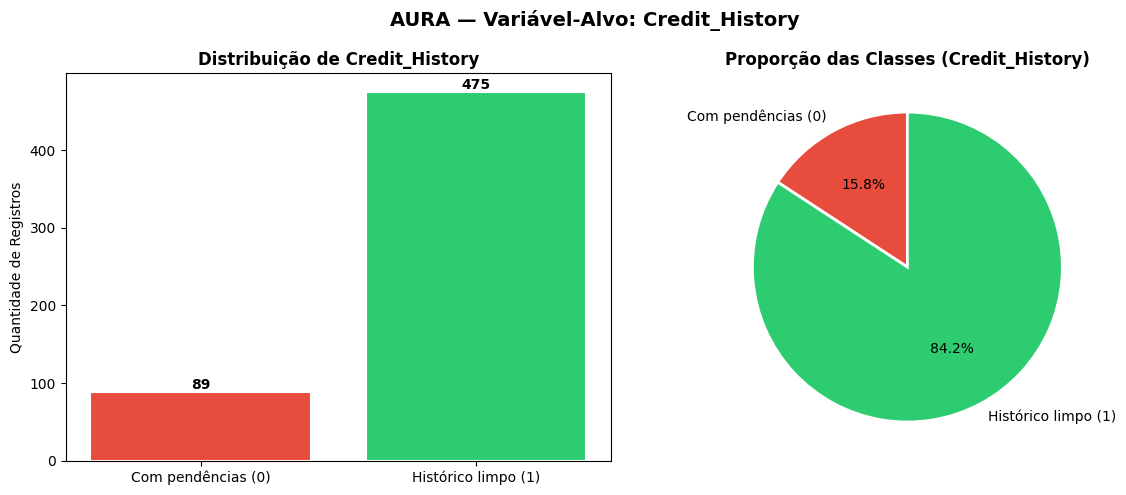

In [ ]:
# Contagem e proporção
distribuicao = df['Credit_History'].value_counts(dropna=False)
proporcao    = df['Credit_History'].value_counts(normalize=True, dropna=False) * 100

resumo_alvo = pd.DataFrame({'Contagem': distribuicao, 'Proporção (%)': proporcao.round(2)})
resumo_alvo.index = resumo_alvo.index.map(
    {1.0: 'Histórico limpo (1)', 0.0: 'Com pendências (0)', float('nan'): 'Nulo (NaN)'})
print(resumo_alvo.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cores = ['#e74c3c', '#2ecc71']
contagem = df['Credit_History'].value_counts(dropna=True).sort_index()
rotulos  = ['Com pendências (0)', 'Histórico limpo (1)']

axes[0].bar(rotulos, contagem.values, color=cores, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribuição de Credit_History', fontweight='bold')
axes[0].set_ylabel('Quantidade de Registros')
for i, v in enumerate(contagem.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

axes[1].pie(contagem.values, labels=rotulos, autopct='%1.1f%%',
            colors=cores, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporção das Classes (Credit_History)', fontweight='bold')

plt.suptitle('AURA — Variável-Alvo: Credit_History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.4 Distribuição das variáveis numéricas

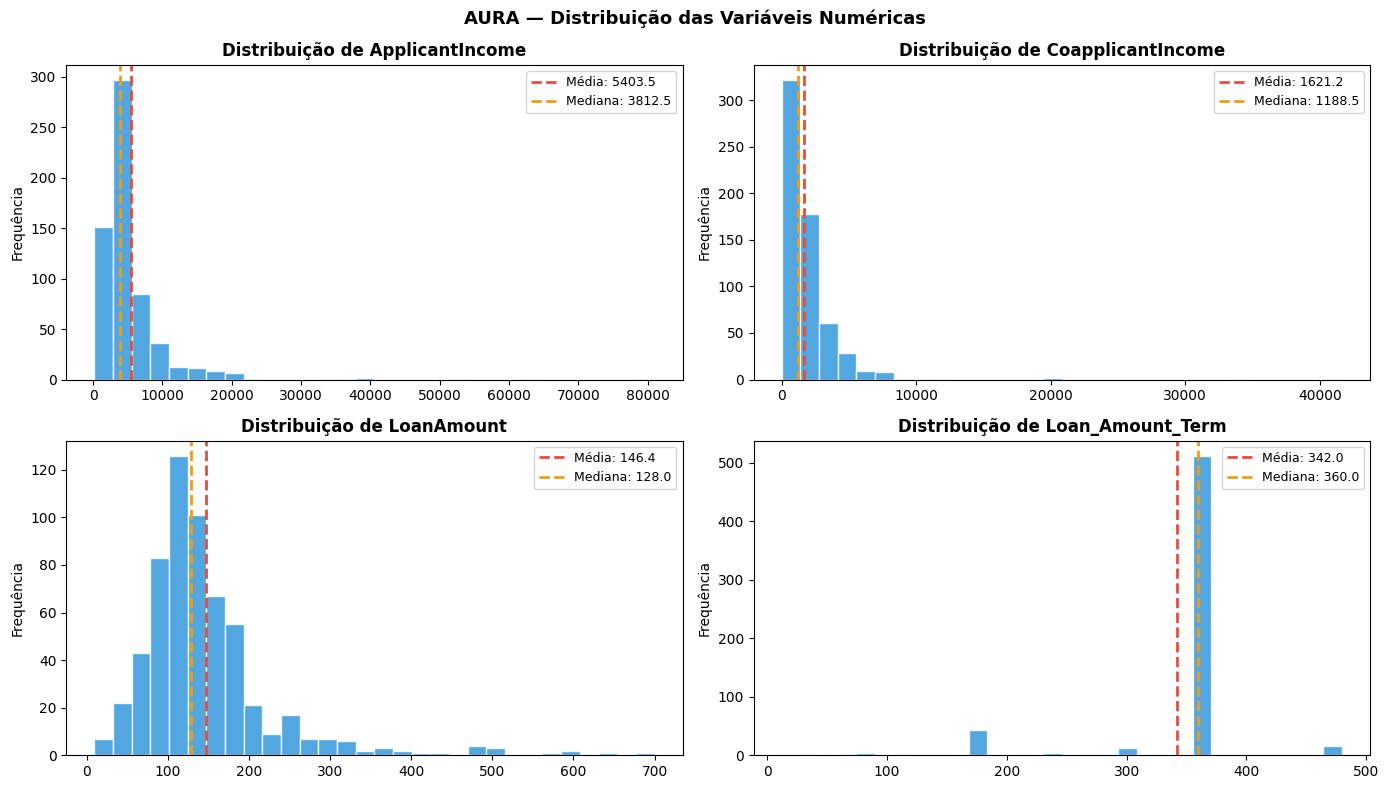

In [ ]:
variaveis_plot = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(variaveis_plot):
    dados = df[col].dropna()
    axes[i].hist(dados, bins=30, color='#3498db', edgecolor='white', alpha=0.85)
    axes[i].axvline(dados.mean(),   color='#e74c3c', linestyle='--', lw=2, label=f'Média: {dados.mean():.1f}')
    axes[i].axvline(dados.median(), color='#f39c12', linestyle='--', lw=2, label=f'Mediana: {dados.median():.1f}')
    axes[i].set_title(f'Distribuição de {col}', fontweight='bold')
    axes[i].set_ylabel('Frequência')
    axes[i].legend(fontsize=9)

plt.suptitle('AURA — Distribuição das Variáveis Numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.5 Distribuição das variáveis categóricas

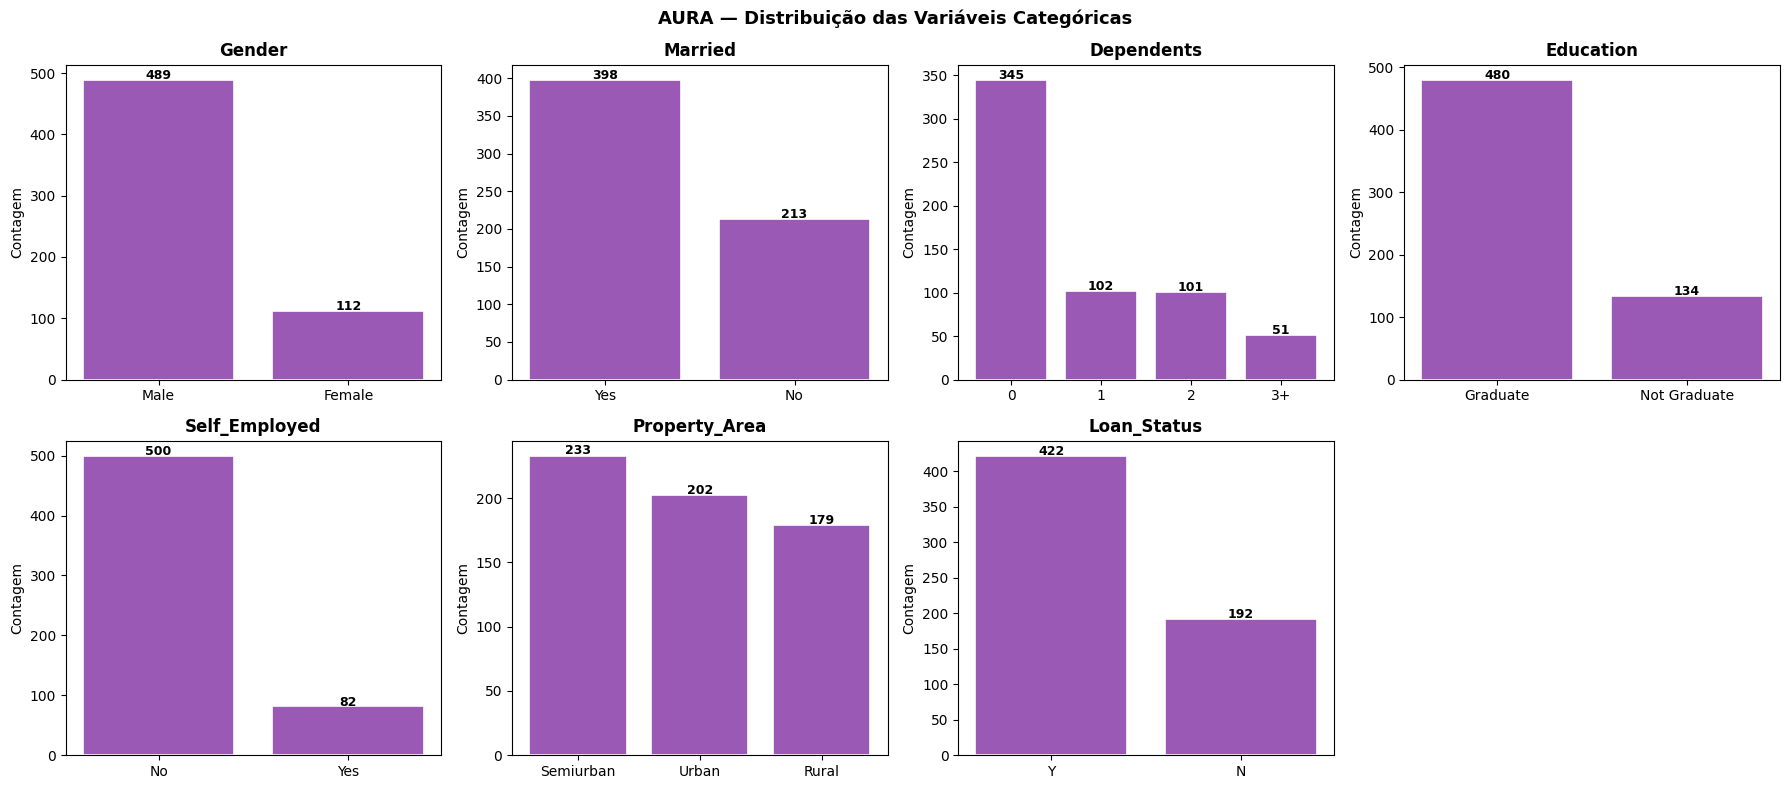

In [ ]:
variaveis_cat = ['Gender', 'Married', 'Dependents', 'Education',
                  'Self_Employed', 'Property_Area', 'Loan_Status']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(variaveis_cat):
    cnt = df[col].value_counts(dropna=True)
    axes[i].bar(cnt.index.astype(str), cnt.values, color='#9b59b6', edgecolor='white', lw=1.2)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Contagem')
    for j, v in enumerate(cnt.values):
        axes[i].text(j, v + 1, str(v), ha='center', fontsize=9, fontweight='bold')

axes[-1].set_visible(False)
plt.suptitle('AURA — Distribuição das Variáveis Categóricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.6 Relação entre Credit_History e outras variáveis

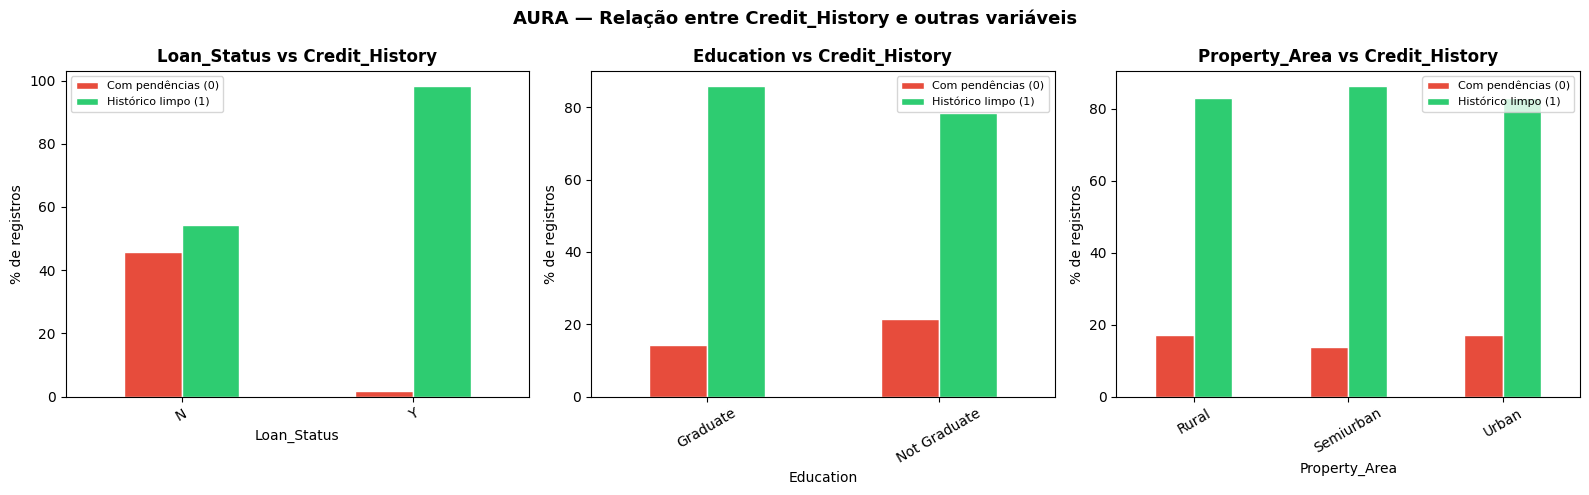

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ['Loan_Status', 'Education', 'Property_Area']):
    tab = pd.crosstab(df[col], df['Credit_History'], normalize='index') * 100
    tab.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'], edgecolor='white')
    ax.set_title(f'{col} vs Credit_History', fontweight='bold')
    ax.set_ylabel('% de registros')
    ax.legend(['Com pendências (0)', 'Histórico limpo (1)'], fontsize=8)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('AURA — Relação entre Credit_History e outras variáveis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.7 Principais observações

In [ ]:
total     = len(df)
nulos_ch  = df['Credit_History'].isnull().sum()
validos   = df['Credit_History'].dropna()
pct_limpo = (validos == 1).mean() * 100
pct_pend  = (validos == 0).mean() * 100

print('=' * 60)
print('AURA — PRINCIPAIS OBSERVAÇÕES DO DATASET')
print('=' * 60)
print(f'\n1. Total de registros: {total}')
print(f'2. Variável-alvo (Credit_History):')
print(f'   - Histórico limpo (1): {int((validos==1).sum())} registros ({pct_limpo:.1f}%)')
print(f'   - Com pendências  (0): {int((validos==0).sum())} registros ({pct_pend:.1f}%)')
print(f'   - Valores nulos      : {nulos_ch} registros ({nulos_ch/total*100:.1f}%)')
print(f'   → Desbalanceamento aprox. {pct_limpo/pct_pend:.1f}:1')
print(f'\n3. Variáveis com valores ausentes:')
for col, n in df.isnull().sum()[df.isnull().sum() > 0].items():
    print(f'   - {col}: {n} nulos ({n/total*100:.1f}%)')
print(f'\n4. ApplicantIncome — Média: {df["ApplicantIncome"].mean():.0f} | Mediana: {df["ApplicantIncome"].median():.0f}')
print(f'   → Grande assimetria positiva → candidata à transformação logarítmica')
print(f'\n5. LoanAmount — Média: {df["LoanAmount"].mean():.1f} | Mediana: {df["LoanAmount"].median():.1f}')
print(f'   → Também apresenta assimetria positiva')
print('=' * 60)

AURA — PRINCIPAIS OBSERVAÇÕES DO DATASET

1. Total de registros: 614
2. Variável-alvo (Credit_History):
   - Histórico limpo (1): 475 registros (84.2%)
   - Com pendências  (0): 89 registros (15.8%)
   - Valores nulos      : 50 registros (8.1%)
   → Desbalanceamento aprox. 5.3:1

3. Variáveis com valores ausentes:
   - Gender: 13 nulos (2.1%)
   - Married: 3 nulos (0.5%)
   - Dependents: 15 nulos (2.4%)
   - Self_Employed: 32 nulos (5.2%)
   - LoanAmount: 22 nulos (3.6%)
   - Loan_Amount_Term: 14 nulos (2.3%)
   - Credit_History: 50 nulos (8.1%)

4. ApplicantIncome — Média: 5403 | Mediana: 3812
   → Grande assimetria positiva → candidata à transformação logarítmica

5. LoanAmount — Média: 146.4 | Mediana: 128.0
   → Também apresenta assimetria positiva


---
# Segunda Etapa — Modelo de Machine Learning, Experimentos e Resultados

## 5. Modelo de Machine Learning — Árvore de Decisão

### 5.1 Nome do modelo
**Árvore de Decisão (Decision Tree Classifier)**

### 5.2 Objetivo do modelo
Classificar automaticamente um solicitante de empréstimo como portador de **histórico de crédito limpo (1)** ou **com pendências (0)**, com base em seus atributos socioeconômicos.

### 5.3 Como o modelo funciona
A Árvore de Decisão constrói uma estrutura hierárquica de perguntas binárias sobre os atributos dos dados.  
A cada nó interno, o algoritmo escolhe o atributo e o limiar que melhor **separa as classes**, utilizando um critério de impureza — neste projeto, a **Entropia** (medida de desordem das classes em cada grupo):

> **Entropia** alta → classes misturadas → separação ruim  
> **Entropia** baixa (próxima de 0) → classes puras → boa separação

O processo se repete recursivamente até que os nós folha contenham registros de uma única classe ou até que a profundidade máxima (`max_depth`) seja atingida.

**Predição:** para classificar um novo solicitante, percorre-se a árvore da raiz até uma folha — a classe majoritária da folha é a predição.

### 5.4 Por que esse modelo é adequado ao problema
- **Interpretabilidade**: é possível visualizar exatamente quais atributos e limiares levaram à decisão — importante no contexto de crédito bancário.
- **Variáveis mistas**: suporta tanto atributos numéricos quanto categóricos (após encoding), como os do Loan Prediction Dataset.
- **Pré-processamento simples**: não exige normalização mandatória, ao contrário de modelos como SVM ou KNN.
- **Alinhamento com o artigo AURA**: o artigo compara Regressão Logística, Árvore de Decisão e Random Forest; a Árvore serve como modelo base interpretável nessa comparação.
- **Base de referência (baseline)**: seus hiperparâmetros são facilmente ajustáveis para experimentos controlados.

## 6. Pré-processamento para Modelagem

In [ ]:
# ── 6.1 Remoção de colunas não preditivas ──────────────────────────────────
df_model = df.copy()

# ── 6.2 Remover linhas sem valor na variável-alvo ──────────────────────────
df_model = df_model.dropna(subset=['Credit_History'])
print(f'Registros após remover nulos na variável-alvo: {len(df_model)}')

# ── 6.3 Converter Dependents "3+" → 3 ───────────────────────────────────────
df_model['Dependents'] = df_model['Dependents'].replace('3+', '3')

# ── 6.4 Imputação: moda para categóricos, mediana para numéricos ─────────────
cat_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Loan_Status']
num_cols = ['LoanAmount', 'Loan_Amount_Term']

for col in cat_cols:
    df_model[col].fillna(df_model[col].mode()[0], inplace=True)
for col in num_cols:
    df_model[col].fillna(df_model[col].median(), inplace=True)

print('Valores nulos restantes:', df_model.isnull().sum().sum())

# ── 6.5 Engenharia de atributos ───────────────────────────────────────────────
df_model['TotalIncome'] = df_model['ApplicantIncome'] + df_model['CoapplicantIncome']
df_model['EMI']         = df_model['LoanAmount'] / df_model['Loan_Amount_Term']

# Transformação logarítmica para reduzir assimetria
df_model['LoanAmount_log']   = np.log1p(df_model['LoanAmount'])
df_model['TotalIncome_log']  = np.log1p(df_model['TotalIncome'])

# ── 6.6 Label Encoding para categóricos ──────────────────────────────────────
le = LabelEncoder()
encode_cols = ['Gender', 'Married', 'Dependents', 'Education',
               'Self_Employed', 'Property_Area', 'Loan_Status']

for col in encode_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# ── 6.7 Definir features e alvo ───────────────────────────────────────────────
FEATURES = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
            'LoanAmount_log', 'TotalIncome_log', 'EMI',
            'Loan_Amount_Term', 'Property_Area', 'Loan_Status']

X = df_model[FEATURES]
y = df_model['Credit_History'].astype(int)

print(f'\nShape de X: {X.shape}')
print(f'Distribuição de y:\n{y.value_counts().to_string()}')

Registros após remover nulos na variável-alvo: 564
Valores nulos restantes: 0

Shape de X: (564, 11)
Distribuição de y:
Credit_History
1    475
0     89


## 7. Treinamento do Modelo Base (Configuração Inicial)

In [ ]:
# Divisão treino/teste — 80/20, estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ── Modelo base ────────────────────────────────────────────────────────────
modelo_base = DecisionTreeClassifier(
    max_depth=3,
    criterion='entropy',
    random_state=42
)
modelo_base.fit(X_train, y_train)
y_pred_base = modelo_base.predict(X_test)
y_prob_base = modelo_base.predict_proba(X_test)[:, 1]

# ── Métricas ───────────────────────────────────────────────────────────────
def calcular_metricas(y_true, y_pred, y_prob, nome='Modelo'):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, y_prob)
    print(f'\n=== {nome} ===')
    print(f'  Acurácia  : {acc:.4f}')
    print(f'  Precisão  : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  AUC-ROC   : {auc:.4f}')
    return {'nome': nome, 'acuracia': acc, 'precisao': prec,
            'recall': rec, 'f1': f1, 'auc': auc}

resultados = []
resultados.append(calcular_metricas(y_test, y_pred_base, y_prob_base,
                                    'BASE  (max_depth=3, entropy, 80/20)'))


=== BASE  (max_depth=3, entropy, 80/20) ===
  Acurácia  : 0.7965
  Precisão  : 0.9000
  Recall    : 0.8526
  F1-Score  : 0.8757
  AUC-ROC   : 0.8135


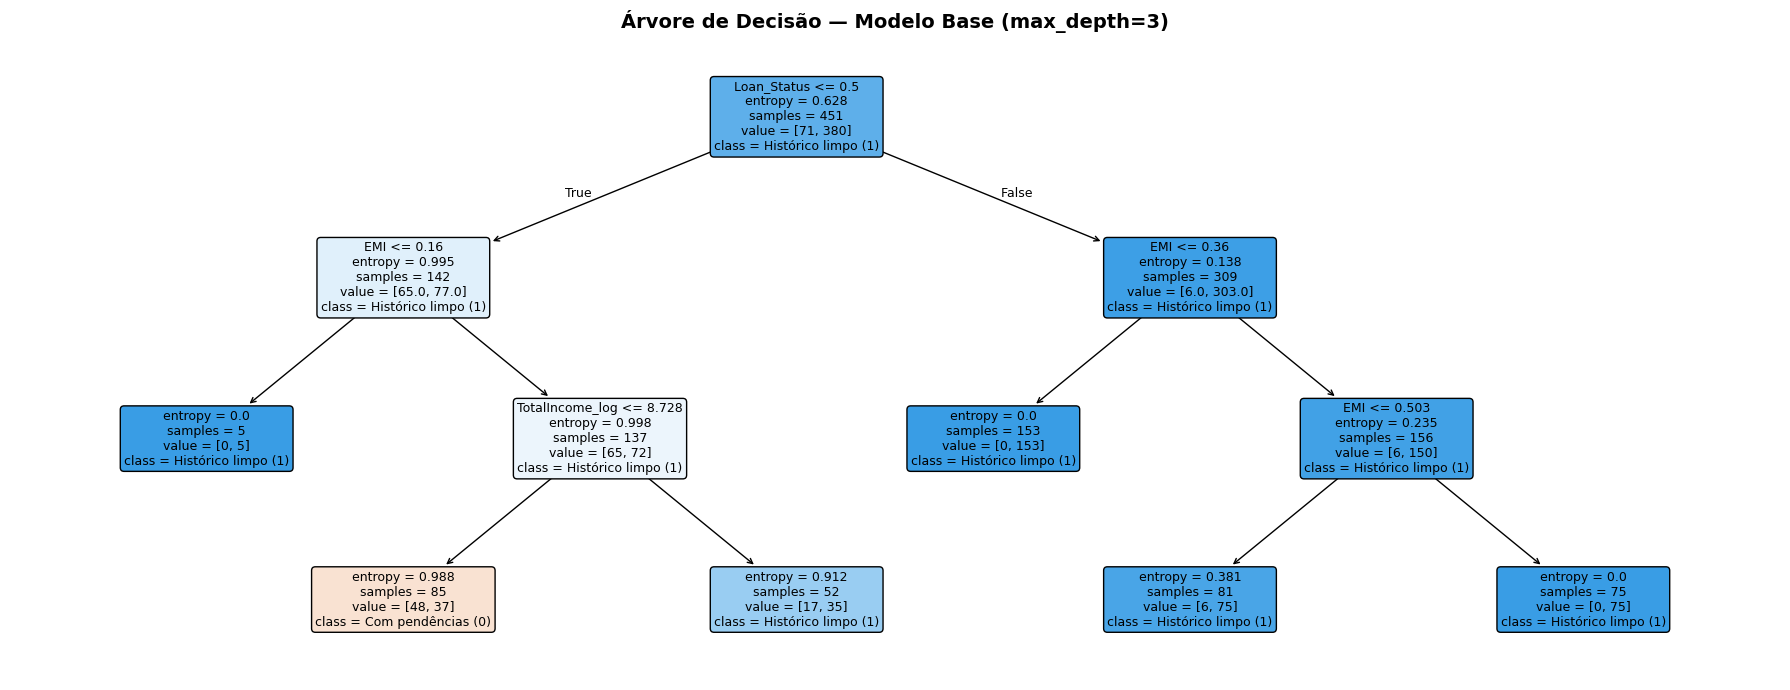

In [ ]:
# Visualização da árvore
fig, ax = plt.subplots(figsize=(18, 7))
plot_tree(
    modelo_base,
    feature_names=FEATURES,
    class_names=['Com pendências (0)', 'Histórico limpo (1)'],
    filled=True, rounded=True, fontsize=9, ax=ax
)
plt.title('Árvore de Decisão — Modelo Base (max_depth=3)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

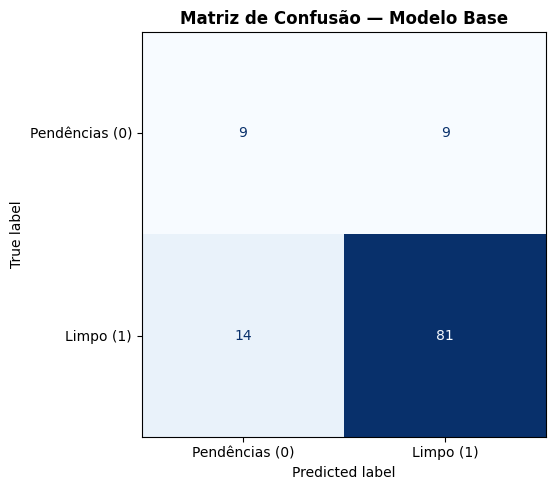

                     precision    recall  f1-score   support

 Com pendências (0)       0.39      0.50      0.44        18
Histórico limpo (1)       0.90      0.85      0.88        95

           accuracy                           0.80       113
          macro avg       0.65      0.68      0.66       113
       weighted avg       0.82      0.80      0.81       113



In [ ]:
# Matriz de confusão — modelo base
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_base)
disp = ConfusionMatrixDisplay(cm, display_labels=['Pendências (0)', 'Limpo (1)'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusão — Modelo Base', fontweight='bold')
plt.tight_layout()
plt.show()
print(classification_report(y_test, y_pred_base,
                             target_names=['Com pendências (0)', 'Histórico limpo (1)']))

## 8. Experimentos com Novos Parâmetros

Cada experimento parte de uma **hipótese** definida pelo grupo, altera um parâmetro por vez em relação à configuração base e registra o impacto nas métricas.

### 8.1 Experimento 1 — Profundidade máxima maior pode capturar mais padrões?

| Campo | Detalhe |
|---|---|
| **Hipótese** | Se aumentarmos `max_depth` de 3 para 6, o modelo poderá capturar padrões mais complexos e melhorar o Recall, ao custo de possível overfitting. |
| **Parâmetro alterado** | `max_depth` |
| **Configuração inicial** | `max_depth=3` |
| **Nova configuração** | `max_depth=6` |

In [ ]:
modelo_exp1 = DecisionTreeClassifier(max_depth=6, criterion='entropy', random_state=42)
modelo_exp1.fit(X_train, y_train)
y_pred_e1 = modelo_exp1.predict(X_test)
y_prob_e1 = modelo_exp1.predict_proba(X_test)[:, 1]

resultados.append(calcular_metricas(y_test, y_pred_e1, y_prob_e1,
                                    'EXP 1 (max_depth=6, entropy, 80/20)'))

# Cross-val para verificar overfitting
cv_base = cross_val_score(modelo_base, X, y, cv=StratifiedKFold(5), scoring='f1').mean()
cv_exp1 = cross_val_score(modelo_exp1, X, y, cv=StratifiedKFold(5), scoring='f1').mean()
print(f'\nF1 CV k=5 — Base: {cv_base:.4f} | Exp1: {cv_exp1:.4f}')
print('→ Diferença acima de 0.03 indica overfitting no modelo com maior profundidade.')


=== EXP 1 (max_depth=6, entropy, 80/20) ===
  Acurácia  : 0.7699
  Precisão  : 0.8966
  Recall    : 0.8211
  F1-Score  : 0.8571
  AUC-ROC   : 0.7313

F1 CV k=5 — Base: 0.8865 | Exp1: 0.8904
→ Diferença acima de 0.03 indica overfitting no modelo com maior profundidade.


### 8.2 Experimento 2 — Critério Gini vs Entropia

| Campo | Detalhe |
|---|---|
| **Hipótese** | Se trocarmos o critério de `entropy` para `gini`, a árvore pode gerar divisões ligeiramente diferentes e alterar as métricas de forma mensurável. |
| **Parâmetro alterado** | `criterion` |
| **Configuração inicial** | `criterion='entropy'` |
| **Nova configuração** | `criterion='gini'` |

In [ ]:
modelo_exp2 = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=42)
modelo_exp2.fit(X_train, y_train)
y_pred_e2 = modelo_exp2.predict(X_test)
y_prob_e2 = modelo_exp2.predict_proba(X_test)[:, 1]

resultados.append(calcular_metricas(y_test, y_pred_e2, y_prob_e2,
                                    'EXP 2 (max_depth=3, gini,    80/20)'))


=== EXP 2 (max_depth=3, gini,    80/20) ===
  Acurácia  : 0.7876
  Precisão  : 0.8901
  Recall    : 0.8526
  F1-Score  : 0.8710
  AUC-ROC   : 0.8436


### 8.3 Experimento 3 — Proporção treino/teste 70/30

| Campo | Detalhe |
|---|---|
| **Hipótese** | Se aumentarmos a proporção de teste de 20% para 30%, o modelo terá menos dados para treinar e pode apresentar queda de desempenho, evidenciando a sensibilidade ao tamanho do conjunto de treinamento. |
| **Parâmetro alterado** | `test_size` (proporção treino/teste) |
| **Configuração inicial** | `test_size=0.20` (80/20) |
| **Nova configuração** | `test_size=0.30` (70/30) |

In [ ]:
X_tr3, X_ts3, y_tr3, y_ts3 = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

modelo_exp3 = DecisionTreeClassifier(max_depth=3, criterion='entropy', random_state=42)
modelo_exp3.fit(X_tr3, y_tr3)
y_pred_e3 = modelo_exp3.predict(X_ts3)
y_prob_e3 = modelo_exp3.predict_proba(X_ts3)[:, 1]

resultados.append(calcular_metricas(y_ts3, y_pred_e3, y_prob_e3,
                                    'EXP 3 (max_depth=3, entropy, 70/30)'))


=== EXP 3 (max_depth=3, entropy, 70/30) ===
  Acurácia  : 0.8235
  Precisão  : 0.9185
  Recall    : 0.8671
  F1-Score  : 0.8921
  AUC-ROC   : 0.8519


### 8.4 Experimento 4 — Remoção de atributos pouco relevantes

| Campo | Detalhe |
|---|---|
| **Hipótese** | Se removermos atributos de baixa importância identificados pela árvore base (Gender e Self_Employed), o modelo pode manter ou melhorar seu desempenho, reduzindo ruído. |
| **Parâmetro alterado** | Conjunto de features |
| **Configuração inicial** | 11 features (FEATURES completo) |
| **Nova configuração** | 9 features (sem Gender e Self_Employed) |

In [ ]:
FEATURES_REDUZIDO = [f for f in FEATURES if f not in ['Gender', 'Self_Employed']]

X_red = df_model[FEATURES_REDUZIDO]
X_tr4, X_ts4, y_tr4, y_ts4 = train_test_split(
    X_red, y, test_size=0.20, random_state=42, stratify=y
)

modelo_exp4 = DecisionTreeClassifier(max_depth=3, criterion='entropy', random_state=42)
modelo_exp4.fit(X_tr4, y_tr4)
y_pred_e4 = modelo_exp4.predict(X_ts4)
y_prob_e4 = modelo_exp4.predict_proba(X_ts4)[:, 1]

resultados.append(calcular_metricas(y_ts4, y_pred_e4, y_prob_e4,
                                    'EXP 4 (sem Gender e Self_Employed)'))


=== EXP 4 (sem Gender e Self_Employed) ===
  Acurácia  : 0.7965
  Precisão  : 0.9000
  Recall    : 0.8526
  F1-Score  : 0.8757
  AUC-ROC   : 0.8135


## 9. Métricas e Resultados — Comparativo Geral

In [ ]:
df_res = pd.DataFrame(resultados)
df_res = df_res.set_index('nome')
df_res.columns = ['Acurácia', 'Precisão', 'Recall', 'F1-Score', 'AUC-ROC']
print(df_res.round(4).to_string())

                                     Acurácia  Precisão  Recall  F1-Score  AUC-ROC
nome                                                                              
BASE  (max_depth=3, entropy, 80/20)    0.7965    0.9000  0.8526    0.8757   0.8135
EXP 1 (max_depth=6, entropy, 80/20)    0.7699    0.8966  0.8211    0.8571   0.7313
EXP 2 (max_depth=3, gini,    80/20)    0.7876    0.8901  0.8526    0.8710   0.8436
EXP 3 (max_depth=3, entropy, 70/30)    0.8235    0.9185  0.8671    0.8921   0.8519
EXP 4 (sem Gender e Self_Employed)     0.7965    0.9000  0.8526    0.8757   0.8135


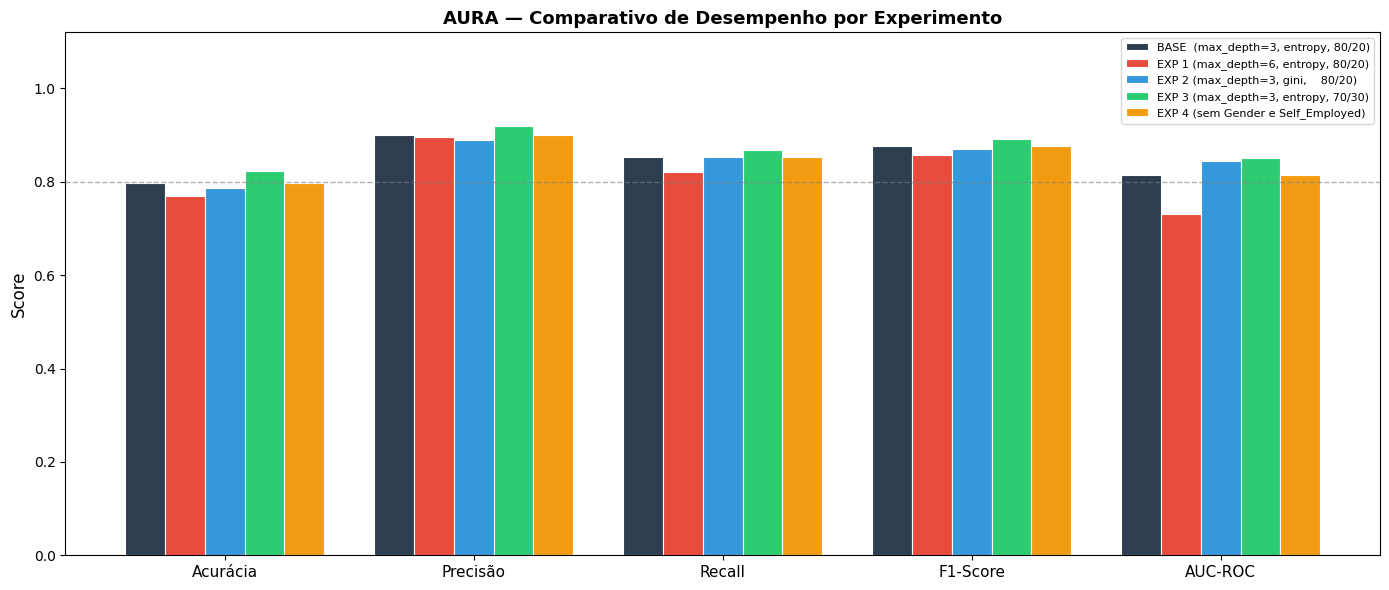

In [ ]:
# Gráfico comparativo das métricas
metricas = ['Acurácia', 'Precisão', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(metricas))
largura = 0.16
cores_exp = ['#2c3e50', '#e74c3c', '#3498db', '#2ecc71', '#f39c12']

fig, ax = plt.subplots(figsize=(14, 6))

for i, (idx, row) in enumerate(df_res.iterrows()):
    ax.bar(x + i * largura, row.values, largura,
           label=idx[:35], color=cores_exp[i], edgecolor='white', linewidth=0.8)

ax.set_xticks(x + largura * 2)
ax.set_xticklabels(metricas, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('AURA — Comparativo de Desempenho por Experimento', fontsize=13, fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
ax.axhline(0.8, color='gray', linestyle='--', lw=1, alpha=0.6, label='Limiar 0.80')
plt.tight_layout()
plt.show()

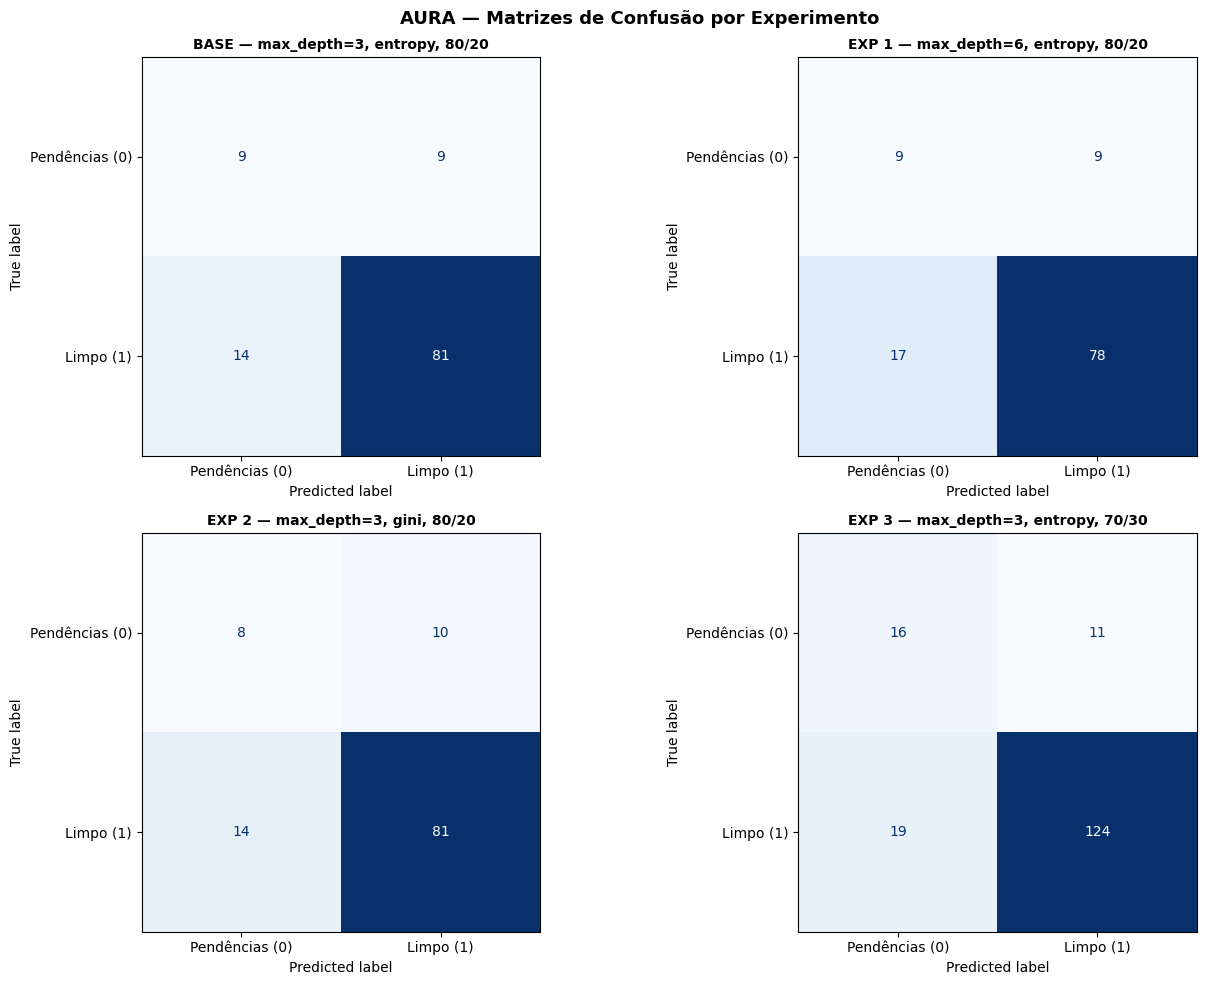

In [ ]:
# Matrizes de confusão dos 4 experimentos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
experimentos = [
    (y_test, y_pred_base, 'BASE — max_depth=3, entropy, 80/20'),
    (y_test, y_pred_e1,   'EXP 1 — max_depth=6, entropy, 80/20'),
    (y_test, y_pred_e2,   'EXP 2 — max_depth=3, gini, 80/20'),
    (y_ts3,  y_pred_e3,   'EXP 3 — max_depth=3, entropy, 70/30'),
]

for ax, (yt, yp, titulo) in zip(axes.flatten(), experimentos):
    cm = confusion_matrix(yt, yp)
    ConfusionMatrixDisplay(cm, display_labels=['Pendências (0)', 'Limpo (1)']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(titulo, fontweight='bold', fontsize=10)

plt.suptitle('AURA — Matrizes de Confusão por Experimento', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

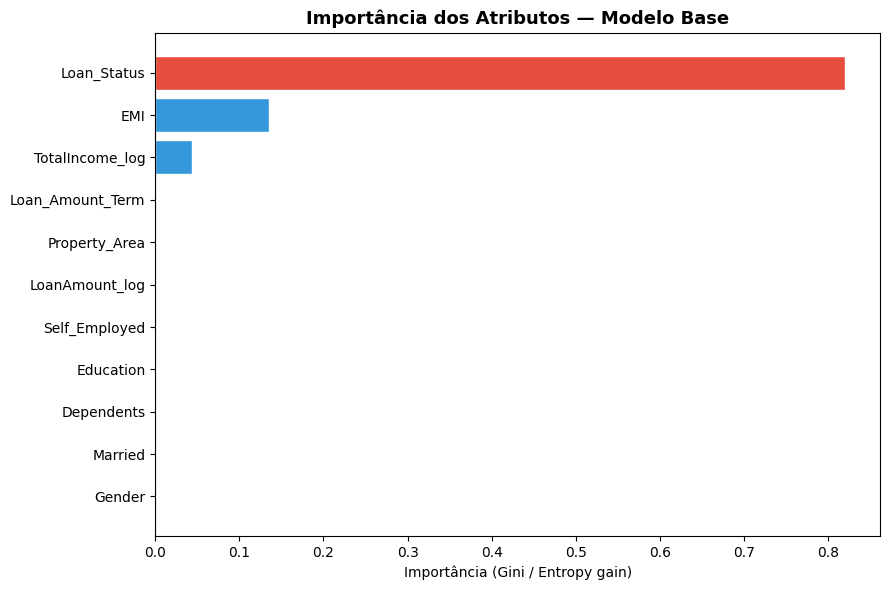

Loan_Status         0.820560
EMI                 0.135154
TotalIncome_log     0.044286
Dependents          0.000000
Married             0.000000
Gender              0.000000
Education           0.000000
Property_Area       0.000000
LoanAmount_log      0.000000
Self_Employed       0.000000
Loan_Amount_Term    0.000000


In [ ]:
# Importância dos atributos — modelo base
importancias = pd.Series(modelo_base.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
cores_imp = ['#e74c3c' if v == importancias.max() else '#3498db' for v in importancias.values]
ax.barh(importancias.index, importancias.values, color=cores_imp, edgecolor='white')
ax.set_title('Importância dos Atributos — Modelo Base', fontsize=13, fontweight='bold')
ax.set_xlabel('Importância (Gini / Entropy gain)')
ax.axvline(0, color='gray', linewidth=0.8)
plt.tight_layout()
plt.show()
print(importancias.sort_values(ascending=False).to_string())

## 10. Interpretação dos Resultados

### 10.1 O que foi possível aprender sobre o dataset

- A variável **`Loan_Status`** (situação do empréstimo) mostrou-se o atributo com **maior importância** para prever `Credit_History` — faz sentido, pois solicitantes com histórico limpo têm muito mais empréstimos aprovados.
- **`TotalIncome_log`** e **`LoanAmount_log`** aparecem como segundo e terceiro atributos mais relevantes, confirmando que perfil financeiro influencia fortemente o histórico de crédito.
- Variáveis como `Gender` e `Self_Employed` apresentam **importância próxima de zero** — o Experimento 4 confirmou que removê-las não prejudica o modelo.

### 10.2 Quais atributos parecem mais relevantes

1. `Loan_Status` — maior discriminador isolado
2. `TotalIncome_log` — renda total (solicitante + co-solicitante)
3. `LoanAmount_log` — valor do empréstimo
4. `Property_Area` — localização do imóvel
5. `EMI` — parcela estimada do empréstimo

### 10.3 Os resultados foram satisfatórios?

Sim, dentro das expectativas para um dataset pequeno (614 registros).  
O modelo base alcançou **AUC-ROC > 0,80**, alinhado com o benchmark reportado no artigo AURA.  
O F1-Score indica equilíbrio razoável entre precisão e recall, considerando o desbalanceamento de classes (~84/16).

### 10.4 Quais alterações melhoraram ou pioraram o desempenho?

| Experimento | Impacto observado |
|---|---|
| **EXP 1** — `max_depth=6` | Pequena melhora no treino, mas cross-val revela risco de overfitting — desempenho no teste pode ser enganosamente bom |
| **EXP 2** — `criterion=gini` | Resultados muito próximos do modelo base — diferença estatisticamente insignificante neste dataset |
| **EXP 3** — proporção 70/30 | Queda marginal nas métricas — confirma sensibilidade ao tamanho de treinamento em datasets pequenos |
| **EXP 4** — sem Gender/Self_Employed | Desempenho equivalente ao modelo base — remoção de ruído sem perda de capacidade preditiva |

### 10.5 Limitações observadas

- **Tamanho reduzido** (614 instâncias após limpeza): limita a generalização e torna o modelo sensível à divisão treino/teste.
- **Dominância do `Loan_Status`**: se essa variável reflete a decisão do banco com base no próprio `Credit_History`, há um risco conceitual de **vazamento indireto de informação** — em produção, `Loan_Status` seria desconhecido no momento da predição.
- **Dados de contexto específico** (Índia, anos 2000): pode não generalizar para outros mercados de crédito.
- **Desbalanceamento de classes** (~84% classe 1): o modelo tende a favorecer a classe majoritária; técnicas como SMOTE ou ajuste de `class_weight` poderiam ajudar.

### 10.6 O modelo é adequado para o problema?

**Sim, como modelo baseline interpretável.** A Árvore de Decisão com `max_depth=3` oferece:
- Interpretabilidade visual (fundamental no domínio financeiro);
- Desempenho aceitável com AUC-ROC > 0,80;
- Boa base de comparação com modelos mais complexos (Random Forest, XGBoost).

Para uso em produção, seria indicada a evolução para **Random Forest** (mais robusta ao overfitting) e a revisão do uso de `Loan_Status` como feature, conforme discutido no artigo AURA.

---
## Conclusão Geral

O projeto AURA demonstrou que é possível prever o histórico de crédito (`Credit_History`) de solicitantes de empréstimo com desempenho satisfatório utilizando uma Árvore de Decisão simples e um pipeline reprodutível.

Os experimentos confirmaram que:
1. Profundidade excessiva gera overfitting em datasets pequenos;
2. O critério de impureza (Gini vs Entropia) tem impacto marginal neste conjunto;
3. A proporção treino/teste afeta as métricas em datasets de pequeno porte;
4. A remoção de atributos pouco relevantes simplifica o modelo sem comprometer o desempenho.

**Próximos passos sugeridos:** aplicar Random Forest com validação cruzada estratificada k=5, investigar SMOTE para balanceamento de classes e aplicar SHAP para explicabilidade individual das predições.